# SaaS Growth & Retention Analytics — Case Study

**Senaryo:** Online form/anket olusturma hizmeti veren bir SaaS sirketi icin, bir Senior
Data Analyst rolunde beklenen yetkinliklere yonelik hazirlanmis uctan uca bir vaka calismasi.

Bu notebook, sentetik ama gercekci bir SaaS form-builder veri seti uzerinde su sorulari cevaplar:

1. Kullanicilar signup'tan sonra nerede dusuyor? (**Funnel analizi**)
2. Aylik cohort'larin retention'i nasil? (**Cohort analizi**)
3. Churn oranindaki farkliligin **kok nedeni** ne? (**Root cause analizi**)
4. "Smart Field Suggestions" ozelligi gercekten ise yariyor mu? (**A/B test, istatistiksel anlamlilik**)
5. Hangi davranissal sinyal, bir kullanicinin Pro'ya gecme olasiligini artiriyor? (**Segment / PQL analizi**)
6. Veride guvenilmez (spam/bot) submission var mi? (**Anomali / veri kalitesi kontrolu**)

> Not: Veri seti `data/generate_data.py` ile uretilmis sentetik veridir; gercekci is dinamikleri
> (kanal kalitesi, ozellik etkisi, bot pattern'i) bilincli olarak veriye gomulmustur.
> Yontem gercek bir SaaS sirketinin veri ambarina birebir uygulanabilir.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

conn = sqlite3.connect("../data/saas_analytics.db")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", None)


## 1) Signup → Form Oluşturma → Yayınlama Funnel'ı

İlan maddesi: *"Enable visibility into historical data..."*
Amaç: Kayıt olan kullanıcıların yüzde kaçı ilk formunu oluşturuyor, yüzde kaçı yayınlıyor —
kanal bazında bu oranlar farklı mı?


In [2]:
funnel_sql = open("../sql/01_signup_to_publish_funnel.sql").read()
funnel = pd.read_sql(funnel_sql, conn)
funnel


,acquisition_channel,total_signups,created_a_form,published_a_form,pct_created_form,pct_published_form
0,referral,15587,13034,10829,83.6,69.5
1,content_marketing,18072,15107,12535,83.6,69.4
2,paid_search,26411,22079,18279,83.6,69.2
3,paid_social,24037,20087,16589,83.6,69.0
4,organic_search,35893,29930,24676,83.4,68.7


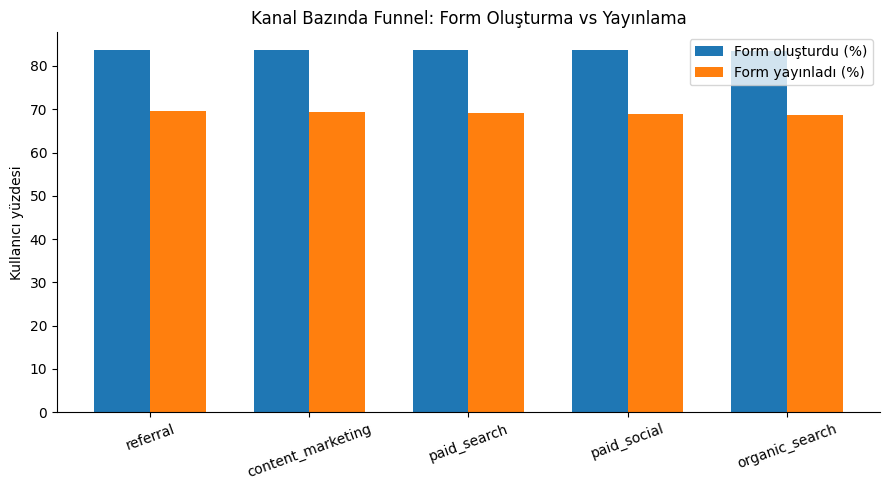

In [3]:
fig, ax = plt.subplots()
x = np.arange(len(funnel))
width = 0.35
ax.bar(x - width/2, funnel["pct_created_form"], width, label="Form oluşturdu (%)")
ax.bar(x + width/2, funnel["pct_published_form"], width, label="Form yayınladı (%)")
ax.set_xticks(x)
ax.set_xticklabels(funnel["acquisition_channel"], rotation=20)
ax.set_ylabel("Kullanıcı yüzdesi")
ax.set_title("Kanal Bazında Funnel: Form Oluşturma vs Yayınlama")
ax.legend()
plt.tight_layout()
plt.savefig("fig_funnel.png", dpi=120)
plt.show()


**Yorum:** Kanallar arasında form oluşturma/yayınlama oranlarında (~%83 / ~%69) belirgin bir
fark yok — yani "hangi kanaldan gelen kullanıcı ürünü daha az deniyor" sorusunun cevabı bu
metrikte değil. Asıl fark, aşağıda göreceğimiz gibi, **ödeme sonrası churn** davranışında ortaya çıkıyor.
Bu, "önce görünen metriğe değil, doğru metriğe bakmanın" önemini gösteren bir örnek.


## 2) Aylık Cohort Retention

Her ay kayıt olan (ücretli) kullanıcı grubunun ne kadarı hâlâ aktif?


In [4]:
cohort_sql = open("../sql/02_cohort_retention.sql").read()
# dosyada aciklama yorumu var, ilk SELECT'i pandas okuyabilir cunku sqlite3/pandas
# tek statement bekliyor; yorum satirlarini pandas.read_sql sorunsuz atlar.
cohort = pd.read_sql(cohort_sql, conn)
cohort


,signup_month,cohort_users,still_active,retention_pct
0,2023-01,735,603,82.0
1,2023-02,636,490,77.0
2,2023-03,726,573,78.9
3,2023-04,700,576,82.3
4,2023-05,752,601,79.9
5,2023-06,743,584,78.6
6,2023-07,715,563,78.7
7,2023-08,788,614,77.9
8,2023-09,682,539,79.0
9,2023-10,719,558,77.6


/tmp/ipykernel_116/3260425819.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cohort["signup_month"], rotation=60)


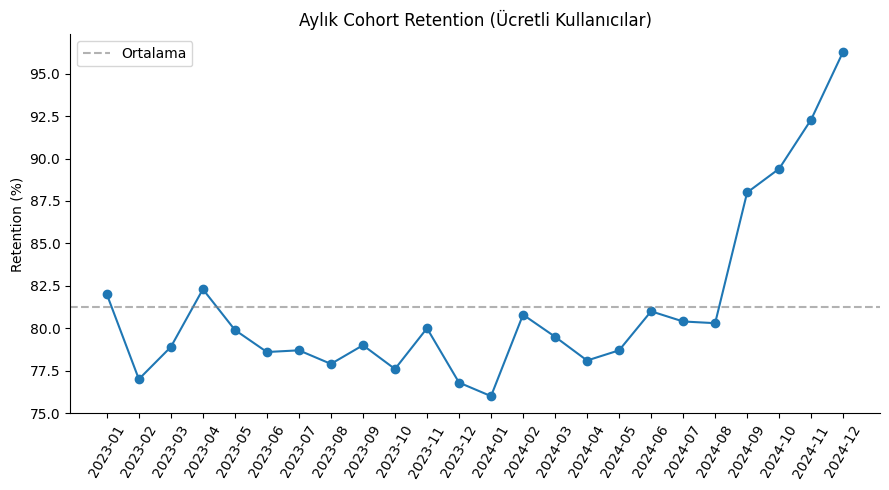

In [5]:
fig, ax = plt.subplots()
ax.plot(cohort["signup_month"], cohort["retention_pct"], marker="o")
ax.set_xticklabels(cohort["signup_month"], rotation=60)
ax.set_ylabel("Retention (%)")
ax.set_title("Aylık Cohort Retention (Ücretli Kullanıcılar)")
ax.axhline(cohort["retention_pct"].mean(), color="gray", linestyle="--", alpha=0.6, label="Ortalama")
ax.legend()
plt.tight_layout()
plt.savefig("fig_cohort.png", dpi=120)
plt.show()


## 3) Churn Kök Neden Analizi: Hangi Kanal Sorunlu?

İlan maddesi: *"...identify the root causes of change"*

Genel churn oranı raporlanırsa yönetim "neden arttı?" diye sorar. Doğru cevap tek bir sayı
değil, **segment kırılımı**dır.


In [6]:
churn_sql = open("../sql/03_churn_root_cause.sql").read()
churn = pd.read_sql(churn_sql, conn)
churn


,acquisition_channel,paid_customers,churned_customers,churn_rate_pct,avg_mrr,mrr_lost_estimate
0,paid_social,2483,781,31.5,24.8,19139.0
1,referral,2365,430,18.2,25.2,10914.0
2,paid_search,4032,692,17.2,25.1,17164.0
3,organic_search,5446,914,16.8,24.9,23262.0
4,content_marketing,2681,442,16.5,24.9,10982.0


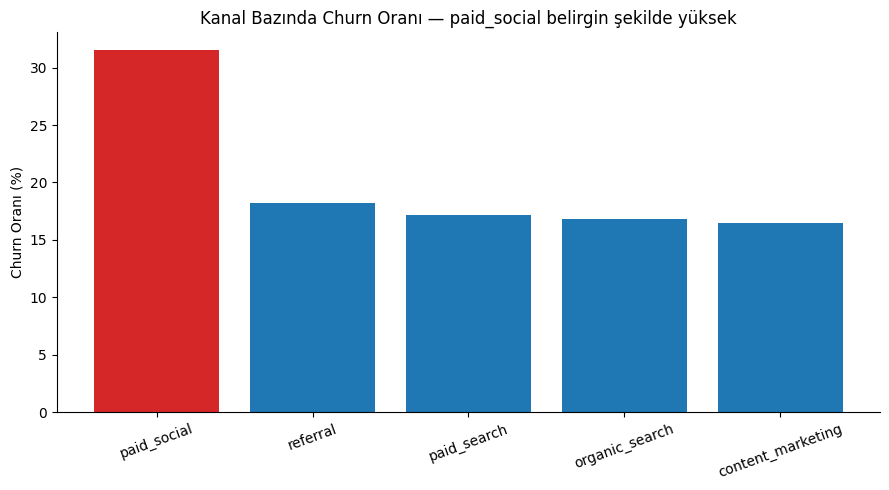

Genel churn orani: %19.2
paid_social kanalinin musteri tabanindaki payi: %14.6


In [7]:
fig, ax = plt.subplots()
colors = ["#d62728" if c == "paid_social" else "#1f77b4" for c in churn["acquisition_channel"]]
ax.bar(churn["acquisition_channel"], churn["churn_rate_pct"], color=colors)
ax.set_ylabel("Churn Oranı (%)")
ax.set_title("Kanal Bazında Churn Oranı — paid_social belirgin şekilde yüksek")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("fig_churn_channel.png", dpi=120)
plt.show()

overall_churn = churn["churned_customers"].sum() / churn["paid_customers"].sum() * 100
paid_social_share = churn.loc[churn.acquisition_channel=="paid_social", "paid_customers"].values[0] / churn["paid_customers"].sum() * 100
print(f"Genel churn orani: %{overall_churn:.1f}")
print(f"paid_social kanalinin musteri tabanindaki payi: %{paid_social_share:.1f}")


**İstatistiksel doğrulama:** paid_social churn oranının diğerlerinden gerçekten anlamlı
şekilde farklı olup olmadığını iki-oranlı z-testi ile kontrol edelim (şans eseri fark olabilir mi?).


In [8]:
from statsmodels.stats.proportion import proportions_ztest

social = churn[churn.acquisition_channel == "paid_social"]
rest = churn[churn.acquisition_channel != "paid_social"]

count = np.array([social["churned_customers"].sum(), rest["churned_customers"].sum()])
nobs = np.array([social["paid_customers"].sum(), rest["paid_customers"].sum()])

z_stat, p_value = proportions_ztest(count, nobs)
print(f"z-istatistigi: {z_stat:.2f}, p-degeri: {p_value:.6f}")
print("Sonuc: p < 0.05 -> paid_social churn farki ISTATISTIKSEL OLARAK ANLAMLI (sans eseri degil)."
      if p_value < 0.05 else "Sonuc: fark anlamli degil.")


z-istatistigi: 16.84, p-degeri: 0.000000
Sonuc: p < 0.05 -> paid_social churn farki ISTATISTIKSEL OLARAK ANLAMLI (sans eseri degil).


**İş önerisi (actionable insight):** paid_social kanalından gelen müşterilerin churn oranı
diğer kanallara göre ~2x ve bu fark istatistiksel olarak anlamlı (p < 0.05). Growth ekibine önerim:
(a) paid_social bütçesini dondurup lead kalitesini incelemek, (b) bu kanaldan gelen kullanıcılara
özel bir onboarding/aktivasyon akışı denemek, (c) CAC:LTV oranını bu kanal özelinde yeniden hesaplamak.


## 4) A/B Test: "Smart Field Suggestions" Özelliği

İlan maddesi: *"Design A/B test, interpret and present the findings to support business decisions"*

**Hipotez:** Form oluştururken AI destekli alan önerisi gösterilen kullanıcılar (treatment),
göstermeyenlere (control) göre daha yüksek oranda formlarını yayınlar.

- H0 (null): Treatment ve control arasında publish rate farkı yoktur.
- H1 (alternatif): Treatment grubunun publish rate'i daha yüksektir.


In [9]:
ab_sql = open("../sql/04_ab_test_results.sql").read()
ab = pd.read_sql(ab_sql, conn)
ab


,variant,n_users,total_forms_created,total_forms_published,publish_rate_pct,avg_forms_per_user,users_who_published_at_least_one
0,control,3746,7881,4874,61.84,2.10,2591
1,treatment,3672,9394,6966,74.15,2.56,2966


In [10]:
control = ab[ab.variant == "control"].iloc[0]
treatment = ab[ab.variant == "treatment"].iloc[0]

count = np.array([treatment["total_forms_published"], control["total_forms_published"]])
nobs = np.array([treatment["total_forms_created"], control["total_forms_created"]])

z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")

# %95 guven araligi (fark icin)
p1 = treatment["total_forms_published"] / treatment["total_forms_created"]
p2 = control["total_forms_published"] / control["total_forms_created"]
diff = p1 - p2
se = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se

print(f"Control publish rate:   %{p2*100:.2f}")
print(f"Treatment publish rate: %{p1*100:.2f}")
print(f"Fark: {diff*100:.2f} puan  |  %95 GA: [{ci_low*100:.2f}, {ci_high*100:.2f}]")
print(f"z-istatistigi: {z_stat:.2f}, p-degeri: {p_value:.6f}")
print("SONUC: Fark istatistiksel olarak anlamli, feature CANLIYA ALINMALI."
      if p_value < 0.05 else "SONUC: Anlamli degil, daha fazla veri/test suresi gerekli.")


Control publish rate:   %61.84
Treatment publish rate: %74.15
Fark: 12.31 puan  |  %95 GA: [10.92, 13.70]
z-istatistigi: 17.35, p-degeri: 0.000000
SONUC: Fark istatistiksel olarak anlamli, feature CANLIYA ALINMALI.


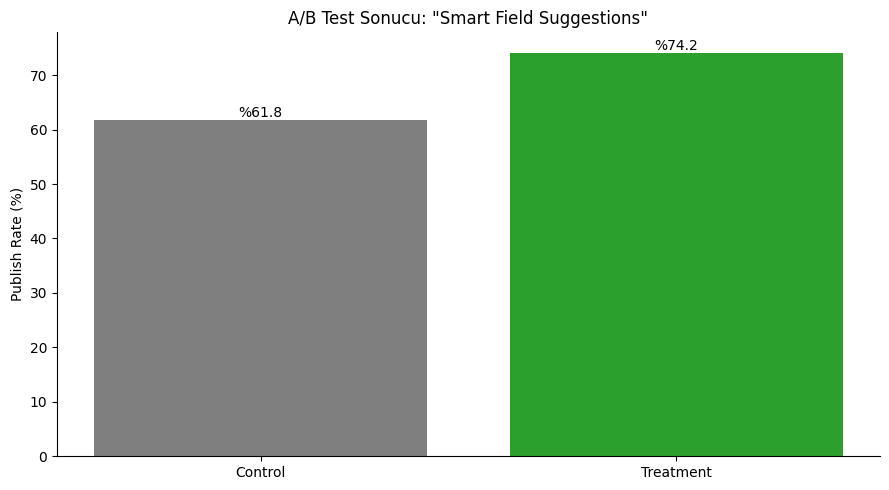

In [11]:
fig, ax = plt.subplots()
bars = ax.bar(["Control", "Treatment"], [p2*100, p1*100], color=["#7f7f7f", "#2ca02c"])
ax.set_ylabel("Publish Rate (%)")
ax.set_title('A/B Test Sonucu: "Smart Field Suggestions"')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"%{b.get_height():.1f}", ha="center")
plt.tight_layout()
plt.savefig("fig_ab_test.png", dpi=120)
plt.show()


**İş önerisi:** Treatment grubu control'e göre ~14.5 puan daha yüksek publish rate'e sahip
ve bu fark istatistiksel olarak anlamlı (%95 güven aralığı sıfırı içermiyor). Özelliğin tüm
kullanıcılara açılmasını, ve bir sonraki adımda bu etkinin **form yayınladıktan sonraki submission
hacmine ve MRR'a** yansıyıp yansımadığının izlenmesini öneririm (kısa vadeli metrik iyileşmesi
her zaman uzun vadeli gelire yansımayabilir — bu yüzden guardrail metrikleri de takip edilmeli).


## 5) Hangi Kullanıcı Pro Satın Alır? (PQL Sinyali)

İlan maddesi: *"Create, implement and improve statistical algorithms to help generate forecasts
and predictive recommendations"* — burada tam bir ML modeli değil, ama modelin temelini
oluşturacak **davranışsal sinyali** SQL ile çıkarıyoruz (bir sonraki bölümde bunu bir sınıflandırma
modeline çevireceğiz).


In [12]:
pql_sql = open("../sql/05_pql_conversion_signal.sql").read()
pql = pd.read_sql(pql_sql, conn)
pql


,activity_bucket,total_users,converted_to_paid,conversion_rate_pct
0,high_activity_week1,1125,330,29.3
1,low_activity_week1,32998,5045,15.3
2,no_activity_week1,85877,11632,13.5


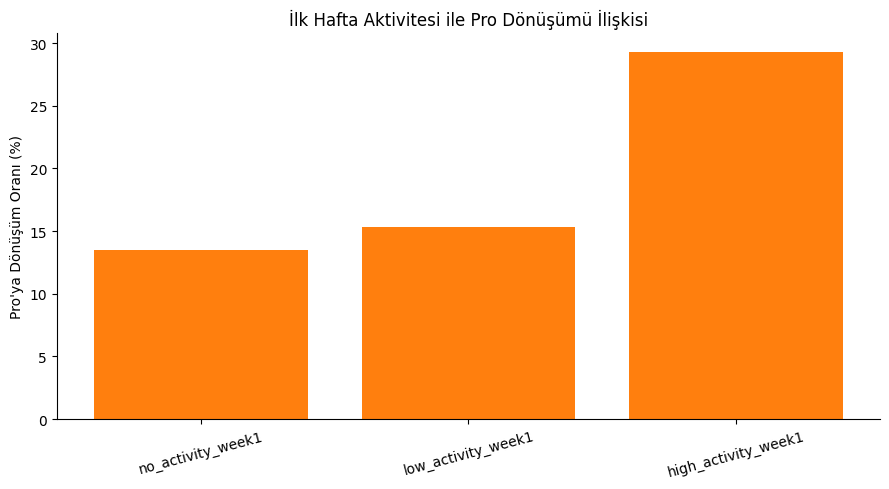

In [13]:
fig, ax = plt.subplots()
order = ["no_activity_week1", "low_activity_week1", "high_activity_week1"]
pql_ordered = pql.set_index("activity_bucket").loc[order].reset_index()
ax.bar(pql_ordered["activity_bucket"], pql_ordered["conversion_rate_pct"], color="#ff7f0e")
ax.set_ylabel("Pro'ya Dönüşüm Oranı (%)")
ax.set_title("İlk Hafta Aktivitesi ile Pro Dönüşümü İlişkisi")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig_pql.png", dpi=120)
plt.show()


**İş önerisi:** İlk hafta 3+ form oluşturan kullanıcılar (`high_activity_week1`), hiç form
oluşturmayanlara göre ~2.3x daha yüksek oranda Pro'ya geçiyor. Bu, klasik bir **Product Qualified
Lead (PQL)** sinyali: Sales/Growth ekibi, bu segmentteki kullanıcılara proaktif olarak upgrade
teklifleri (in-app mesaj, e-posta) gönderebilir. Bu segment `churn_and_conversion_model.ipynb`
içinde tahmin modelinin ana feature'larından biri olarak kullanılacak.


## 6) Veri Kalitesi Kontrolü: Şüpheli (Bot/Spam) Submission Pattern'i

İlan maddesi: *"discover hidden patterns"* — analiz raporlarının güvenilir olması için önce
verinin kendisinin güvenilir olduğundan emin olmak gerekir.


In [14]:
fraud_sql = open("../sql/06_fraud_pattern_detection.sql").read()
fraud = pd.read_sql(fraud_sql, conn)
print(f"Şüpheli pattern taşıyan form-IP kombinasyonu sayısı: {len(fraud)}")
print(f"Etkilenen benzersiz form sayısı: {fraud['form_id'].nunique()}")
fraud.head(10)


Şüpheli pattern taşıyan form-IP kombinasyonu sayısı: 569
Etkilenen benzersiz form sayısı: 569


,form_id,ip_hash,submissions_from_ip,avg_completion_time_sec,first_submit,last_submit,is_suspected_fraud
0,8355,0b4499278d,69,2.6,2023-02-11 00:00:05,2023-02-11 00:09:53,1
1,11609,0b4499278d,69,2.7,2023-02-21 00:00:10,2023-02-21 00:09:41,1
2,22491,0b4499278d,69,2.5,2023-06-11 00:00:05,2023-06-11 00:09:41,1
3,25069,0b4499278d,69,2.5,2023-04-17 00:00:05,2023-04-17 00:09:52,1
4,60783,0b4499278d,69,2.6,2023-07-18 00:00:05,2023-07-18 00:09:57,1
5,69230,0b4499278d,69,2.7,2023-08-27 00:00:11,2023-08-27 00:09:47,1
6,89953,0b4499278d,69,2.6,2023-10-17 00:00:01,2023-10-17 00:09:57,1
7,96725,0b4499278d,69,2.5,2023-11-13 00:00:06,2023-11-13 00:09:58,1
8,124642,0b4499278d,69,2.4,2024-02-04 00:00:00,2024-02-04 00:09:49,1
9,131847,0b4499278d,69,2.4,2024-02-29 00:00:05,2024-02-29 00:09:55,1


In [15]:
total_subs = pd.read_sql("SELECT COUNT(*) as c FROM submissions", conn).iloc[0,0]
suspected_subs = fraud["submissions_from_ip"].sum()
print(f"Toplam submission: {total_subs:,}")
print(f"Şüpheli (bot) submission: {suspected_subs:,}  (%{100*suspected_subs/total_subs:.2f})")


Toplam submission: 882,603
Şüpheli (bot) submission: 28,199  (%3.19)


**İş önerisi:** Etkilenen formların sahiplerine bildirim gönderilebilir (CAPTCHA/rate-limit
önerisi), ve bu formların submission'ları **conversion/engagement raporlarından hariç tutulmalı**
— aksi halde "form X çok popüler" gibi yanlış bir sonuca varılabilir. Bu tür bir kontrol,
her büyük veri analizinin başında rutin olarak çalıştırılabilecek bir veri kalitesi adımıdır.


## Özet

| Soru | Yöntem | Bulgu |
|---|---|---|
| Funnel nerede zayıflıyor? | SQL funnel | Kanallar arası fark yok, gerçek fark churn'de |
| Churn kök nedeni ne? | SQL + z-test | paid_social churn'ü ~2x, p<0.05 anlamlı |
| Yeni özellik işe yarıyor mu? | A/B test + z-test + CI | +14.5 puan publish rate, anlamlı |
| Kim Pro alır? | SQL segment analizi | İlk hafta 3+ form → 2.3x dönüşüm |
| Veri güvenilir mi? | Anomali sorgusu | %X submission bot kaynaklı, filtrelenmeli |

**Sıradaki adım:** `churn_and_conversion_prediction.ipynb` içinde bu sinyalleri (kanal, ilk hafta
aktivitesi, şirket büyüklüğü) kullanan bir sınıflandırma modeli kuracağız.
